# 🦖 EPOCH Pilot Task
> 주제: 신용카드 고객 이탈 예측 모델 구축을 통한 이탈 요인 분석 및 대응 전략

### 0. 데이터 설명 / 불러오기

* 데이터: Kaggle - Credit Card customers
(https://www.kaggle.com/datasets/sakshigoyal7/credit-card-customers)

* 개요: This dataset consists of 10,000 customers mentioning their age, salary, marital_status, credit card limit, credit card category, etc. There are nearly 18 features. We have only 16.07% of customers who have churned.

> features

✏️ **고객 식별 및 타겟 변수**
* CLIENTNUM: 고객 번호 (고유 식별자)

* Attrition_Flag: 이탈 여부 (해지하면 1, 유지 중이면 0)

***

✏️ **인구통계학적 변수**
* Customer_Age: 나이 (만 나이)

* Gender: 성별

* Dependent_count: 부양가족 수

* Education_Level: 학력 수준 (예: 고졸, 대졸, 대학원 등)

* Matiral_Status: 결혼 상태 (기혼, 미혼, 이혼, 미상)

* Income_Category: 연 소득 (소득 구간)

***

✏️ **카드/상품 관련 변수**

* Card_Category: 카드 등급 (Blue, Silver, Gold, Platinum)

* Months_on_book: 거래 유지 기간 (개월 단위)

* Total_Relationship_Count: 보유한 은행 상품의 총 개수

* Months_Inactive_12_mon: 최근 12개월 중 카드 사용이 없던 개월 수

* Contacts_Count_12_mon: 최근 12개월 고객센터 접촉 횟수

* Credit_Limit: 신용카드 한도 금액

* Total_Revolving_Bal: 총 리볼빙 잔액 (결제하지 않고 이월된 금액)

* Avg_Open_To_Buy: 최근 12개월 평균 사용 가능한 잔여 한도 (신용한도-사용금액)

* Total_Amt_Chng_Q4_Q1: 4분기 대비 1분기 거래 금액 변화율

* Total_Trans_Amt: 최근 12개월 총 거래 금액

* Total_Trans_Ct: 최근 12개월 총 거래 횟수

* Total_Ct_Chng_Q4_Q1: 4분기 대비 1분기 거래 횟수 변화율

* Avg_Utilization_Ratio: 평균 카드 사용률 (사용금액/신용한도)

***

✏️ **Naive Bayes 관련 변수**

* Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1: 나이브 베이즈 모델이 예측한 이탈 확률값

* Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2: 나이브 베이즈 모델이 예측한 유지 확률값


> 데이터 불러오기

In [42]:
# 필요한 라이브러리
import math
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import train_test_split, cross_val_score

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.metrics import recall_score, precision_score, precision_recall_curve
from sklearn.metrics import average_precision_score, roc_curve, auc, f1_score

from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
# 데이터 불러오기
df = pd.read_csv('/content/drive/MyDrive/BankChurners.csv')

### 1. 데이터 확인 / EDA

> 데이터 확인

In [4]:
df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [5]:
df.tail()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
10122,772366833,Existing Customer,50,M,2,Graduate,Single,$40K - $60K,Blue,40,...,4003.0,1851,2152.0,0.703,15476,117,0.857,0.462,0.000191,0.999810
10123,710638233,Attrited Customer,41,M,2,Unknown,Divorced,$40K - $60K,Blue,25,...,4277.0,2186,2091.0,0.804,8764,69,0.683,0.511,0.995270,0.004729
10124,716506083,Attrited Customer,44,F,1,High School,Married,Less than $40K,Blue,36,...,5409.0,0,5409.0,0.819,10291,60,0.818,0.000,0.997880,0.002118
10125,717406983,Attrited Customer,30,M,2,Graduate,Unknown,$40K - $60K,Blue,36,...,5281.0,0,5281.0,0.535,8395,62,0.722,0.000,0.996710,0.003294
10126,714337233,Attrited Customer,43,F,2,Graduate,Married,Less than $40K,Silver,25,...,10388.0,1961,8427.0,0.703,10294,61,0.649,0.189,0.996620,0.003377


In [6]:
# 분석에 필요없는 마지막 2개 특성 삭제
df = df.iloc[:, :-2]

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 10127 non-null  int64  
 1   Attrition_Flag            10127 non-null  object 
 2   Customer_Age              10127 non-null  int64  
 3   Gender                    10127 non-null  object 
 4   Dependent_count           10127 non-null  int64  
 5   Education_Level           10127 non-null  object 
 6   Marital_Status            10127 non-null  object 
 7   Income_Category           10127 non-null  object 
 8   Card_Category             10127 non-null  object 
 9   Months_on_book            10127 non-null  int64  
 10  Total_Relationship_Count  10127 non-null  int64  
 11  Months_Inactive_12_mon    10127 non-null  int64  
 12  Contacts_Count_12_mon     10127 non-null  int64  
 13  Credit_Limit              10127 non-null  float64
 14  Total_

In [8]:
# 수치형 변수 확인
df.describe()

,CLIENTNUM,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
count,1.012700e+04,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,7.391776e+08,46.325960,2.346203,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894
std,3.690378e+07,8.016814,1.298908,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691
min,7.080821e+08,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000
25%,7.130368e+08,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000
50%,7.179264e+08,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000
75%,7.731435e+08,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000
max,8.283431e+08,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000


In [9]:
# 범주형 변수 확인
df.describe(include='object').T

,count,unique,top,freq
Attrition_Flag,10127,2,Existing Customer,8500
Gender,10127,2,F,5358
Education_Level,10127,7,Graduate,3128
Marital_Status,10127,4,Married,4687
Income_Category,10127,6,Less than $40K,3561
Card_Category,10127,4,Blue,9436


In [10]:
# 결측치 확인
df.isnull().sum()

,0
CLIENTNUM,0
Attrition_Flag,0
Customer_Age,0
Gender,0
Dependent_count,0
Education_Level,0
Marital_Status,0
Income_Category,0
Card_Category,0
Months_on_book,0


In [11]:
# 중복치 확인
df.duplicated().sum()

np.int64(0)

> EDA

이탈률 약 16%인 불균형 데이터

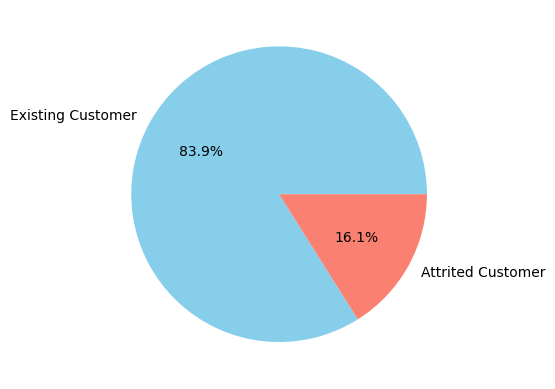

In [12]:
# 이탈률 확인
df['Attrition_Flag'].value_counts().plot.pie(autopct='%1.1f%%',
                                             colors=['skyblue', 'salmon'])
plt.ylabel('')
plt.show()

In [13]:
# 1. Attrition_Flag를 기반으로 'churn' 컬럼 생성 (이탈=1, 유지=0)
df['churn'] = df['Attrition_Flag'].apply(lambda x: 1 if x == 'Attrited Customer' else 0)

# 2. 범주형 변수 자동 추출 (object 또는 category 타입)
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# 3. 분석에 불필요한 타겟 변수 및 ID성 컬럼 제외
exclude_cols = ['Attrition_Flag', 'churn', 'CLIENTNUM']
categorical_cols = [col for col in categorical_cols if col not in exclude_cols]

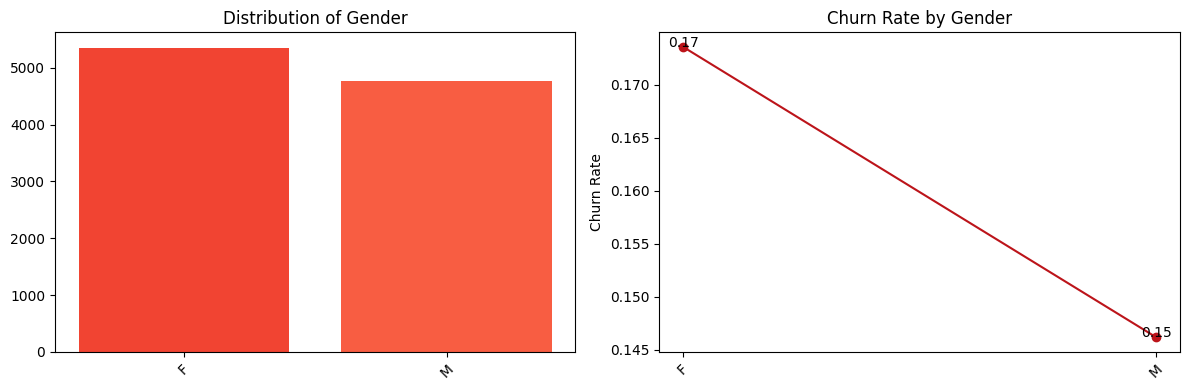

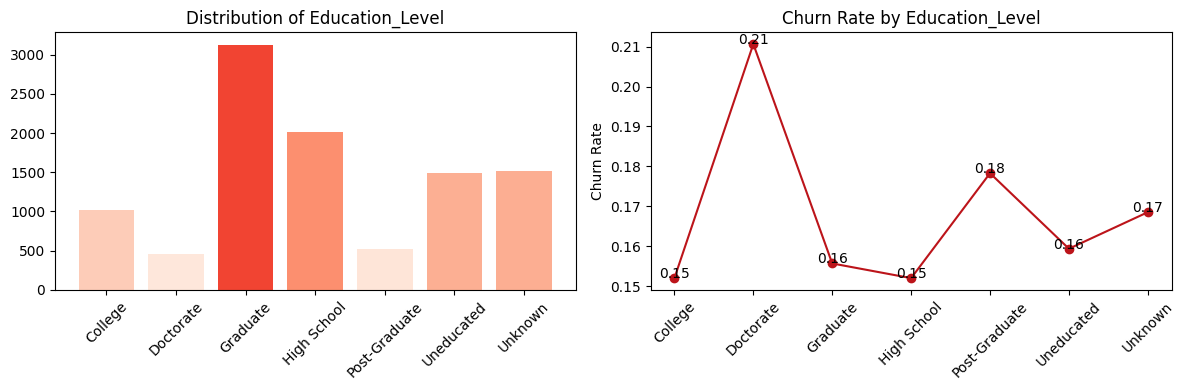

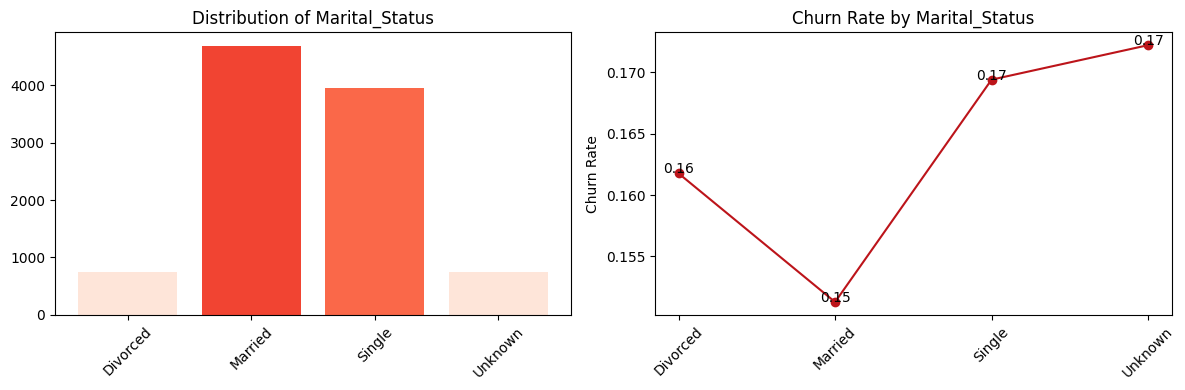

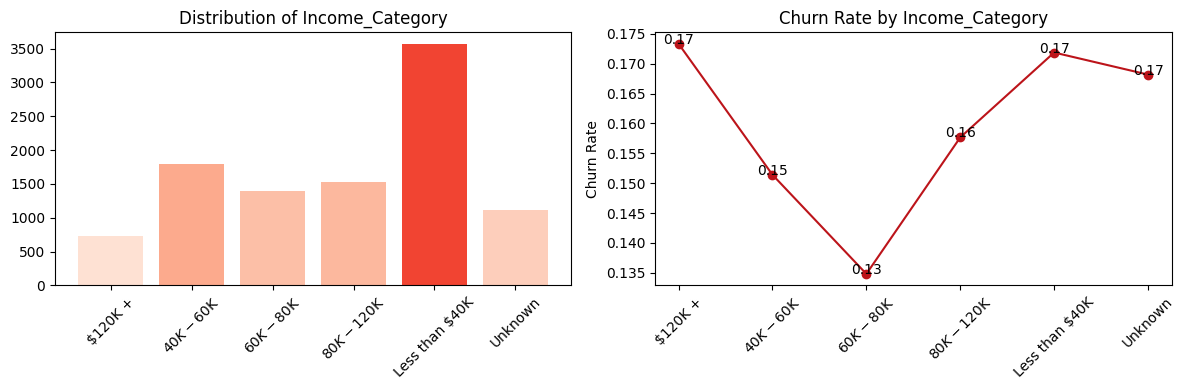

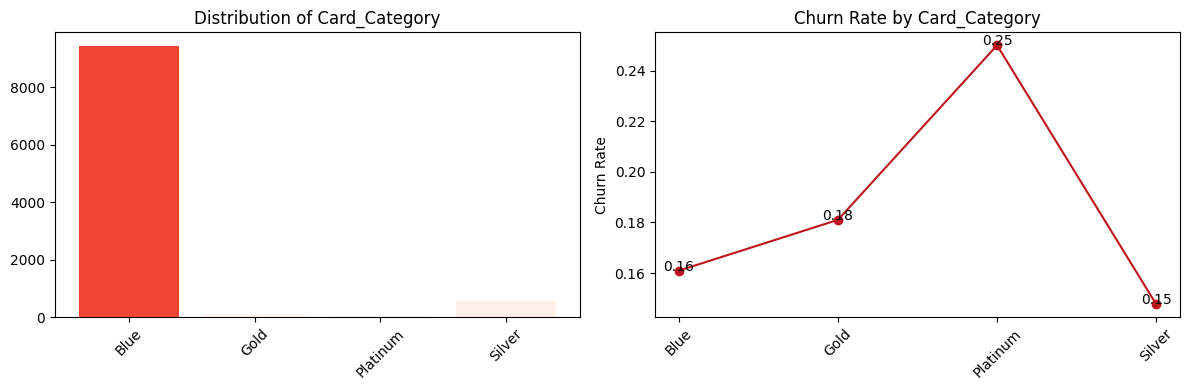

In [14]:
# 범주형 변수 확인
for col in categorical_cols:

    fig, axes = plt.subplots(1,2,figsize=(12,4))

    # 분포
    counts = df.groupby(col).size()

    colors = plt.cm.Reds(0.6 * counts.values / counts.values.max())

    axes[0].bar(counts.index, counts.values, color=colors)
    axes[0].set_title(f'Distribution of {col}')
    axes[0].tick_params(axis='x', rotation=45)

    # 이탈률
    churn_rate = df.groupby(col)['churn'].mean()
    axes[1].plot(churn_rate.index, churn_rate.values, marker='o',
                 color=plt.cm.Reds(0.8))

    axes[1].set_title(f'Churn Rate by {col}')
    axes[1].set_ylabel('Churn Rate')

    for i,v in enumerate(churn_rate.values):
        axes[1].text(i,v,f'{v:.2f}',ha='center')

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [15]:
# 수치형 변수 구분 (이산형/연속형)
# ID, 타겟 제외
exclude_cols = ['CLIENTNUM', 'Attrition_Flag', 'churn']

# 수치형 전체
numeric_cols = df.select_dtypes(include=['int64','float64']).columns
numeric_cols = [c for c in numeric_cols if c not in exclude_cols]

# 이산형(카운트형) 후보: 고유값 개수가 적은 정수형
discrete_cols = [c for c in numeric_cols 
                 if (df[c].nunique() <= 10) and (pd.api.types.is_integer_dtype(df[c]))]

# 연속형: 나머지
continuous_cols = [c for c in numeric_cols if c not in discrete_cols]

print("Discrete:", discrete_cols)
print("Continuous:", continuous_cols)

Discrete: ['Dependent_count', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon']
Continuous: ['Customer_Age', 'Months_on_book', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']


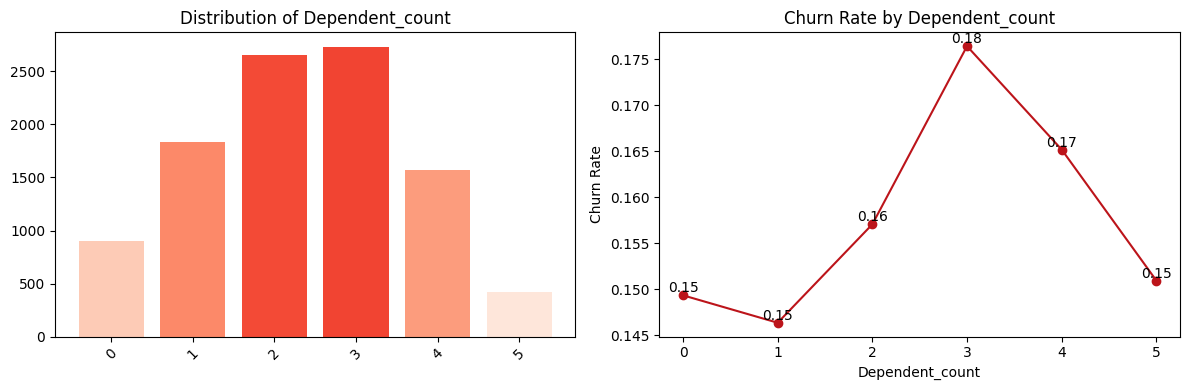

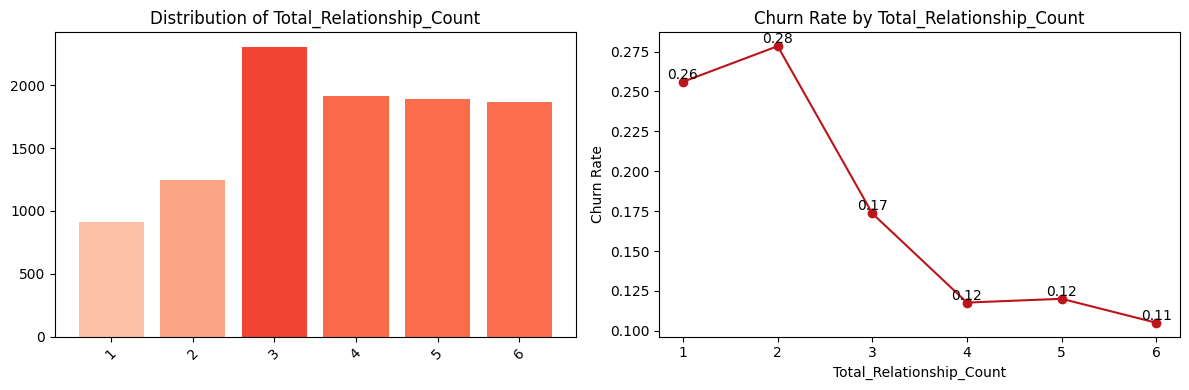

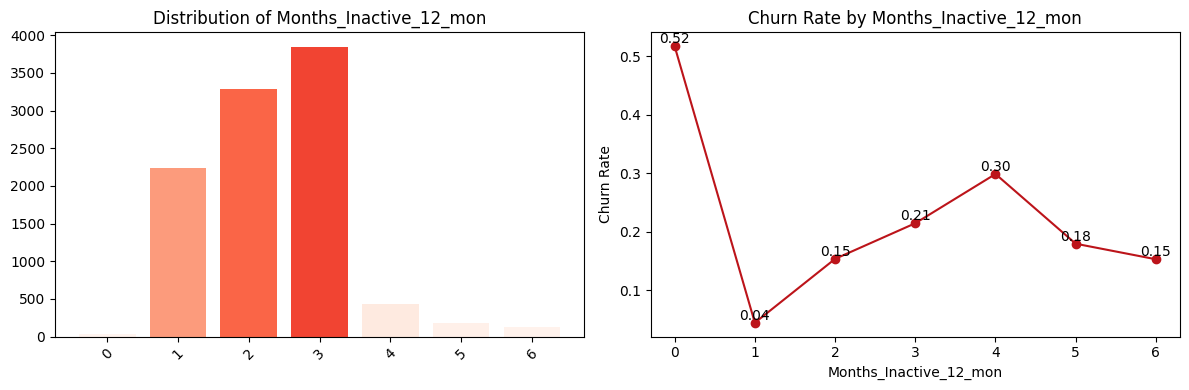

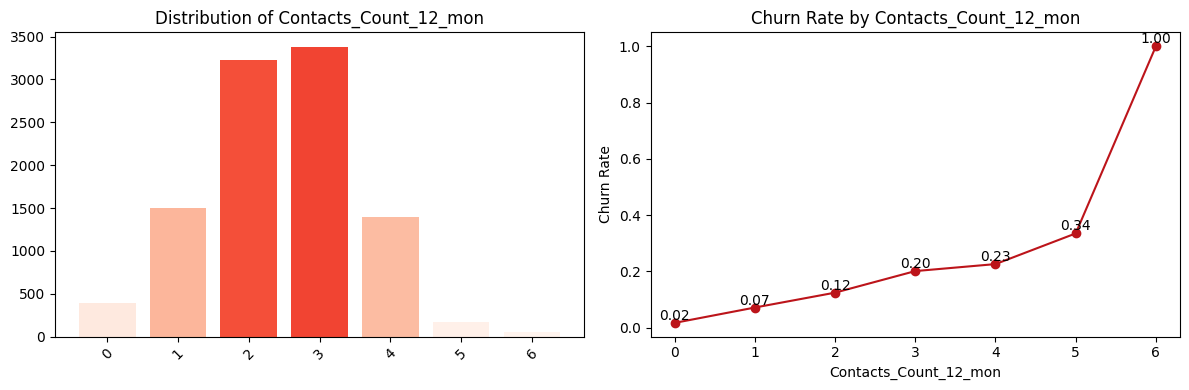

In [16]:
# 이산형 변수 확인
for col in discrete_cols:

    fig, axes = plt.subplots(1, 2, figsize=(12,4))

    # 분포
    counts = df.groupby(col).size()

    colors = plt.cm.Reds(0.6 * counts.values / counts.values.max())

    axes[0].bar(counts.index, counts.values, color=colors)
    axes[0].set_title(f'Distribution of {col}')
    axes[0].tick_params(axis='x', rotation=45)

    # 이탈률
    churn_rate = df.groupby(col)['churn'].mean()

    axes[1].plot(churn_rate.index.astype(str), churn_rate.values, marker='o',
                 color=plt.cm.Reds(0.8))
    axes[1].set_title(f'Churn Rate by {col}')
    axes[1].set_ylabel('Churn Rate')
    axes[1].set_xlabel(col)

    # 숫자 표시
    for i, v in enumerate(churn_rate.values):
        axes[1].text(i, v, f'{v:.2f}', ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

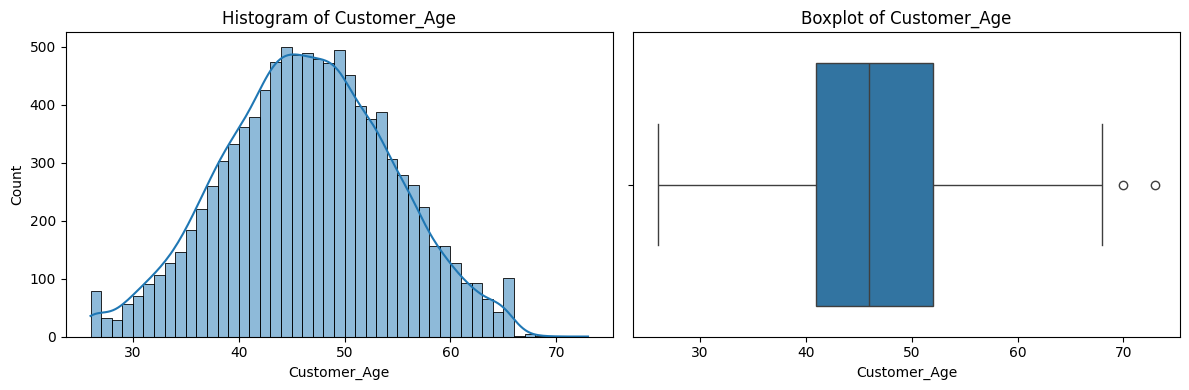

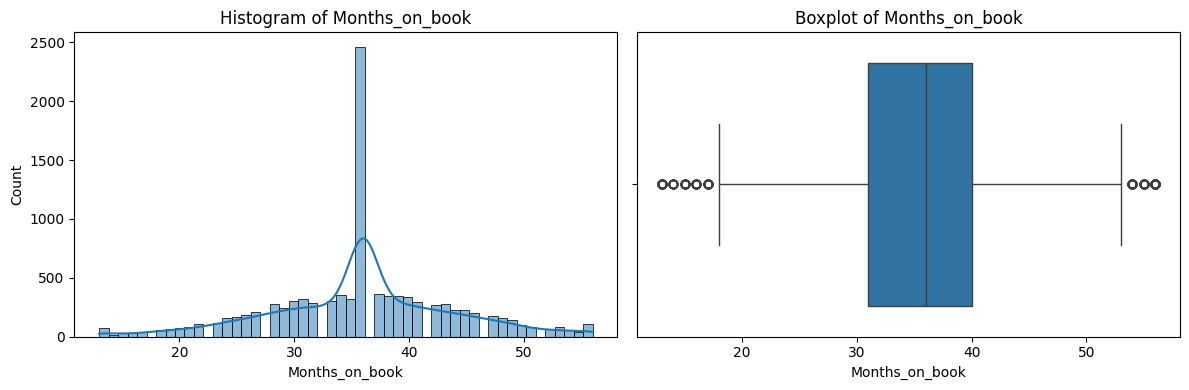

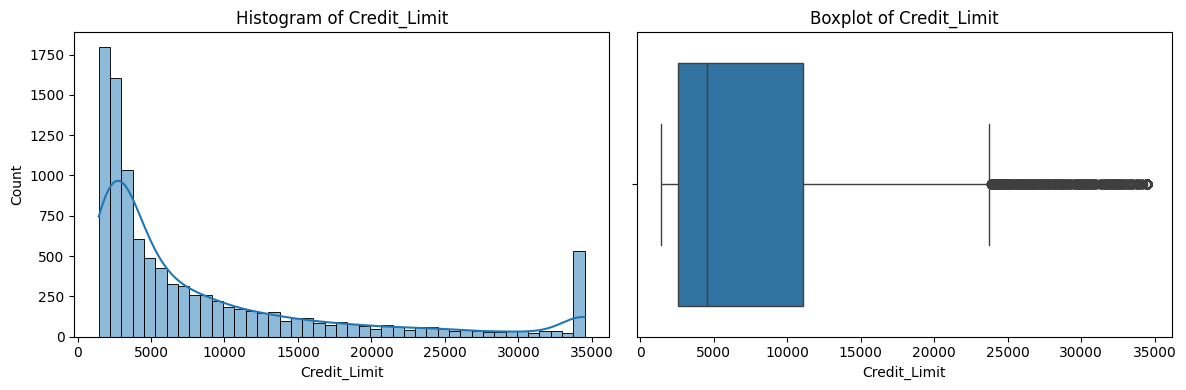

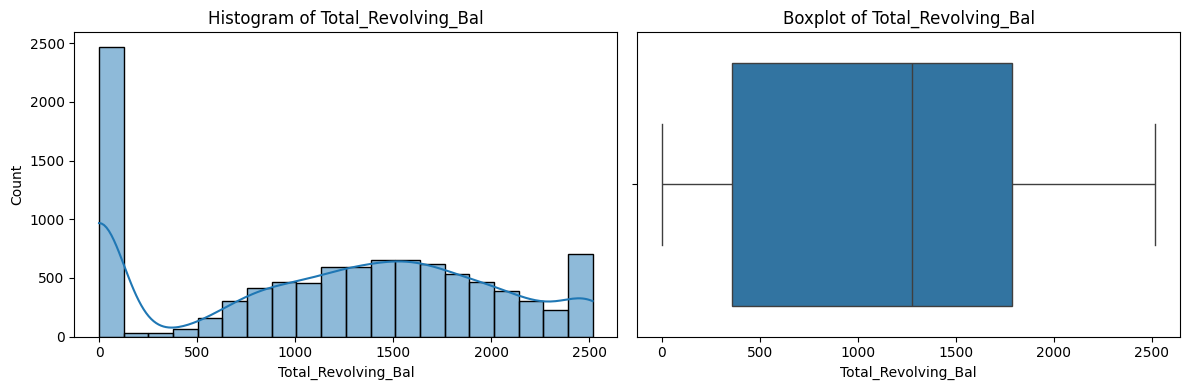

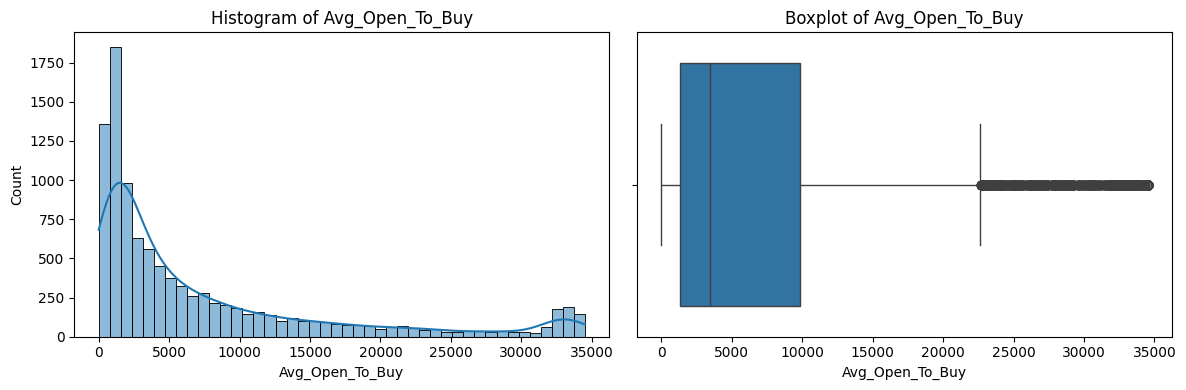

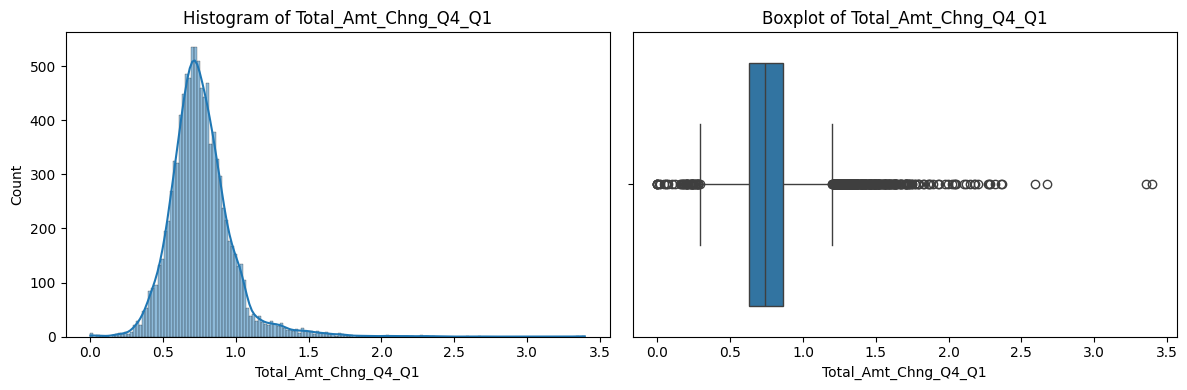

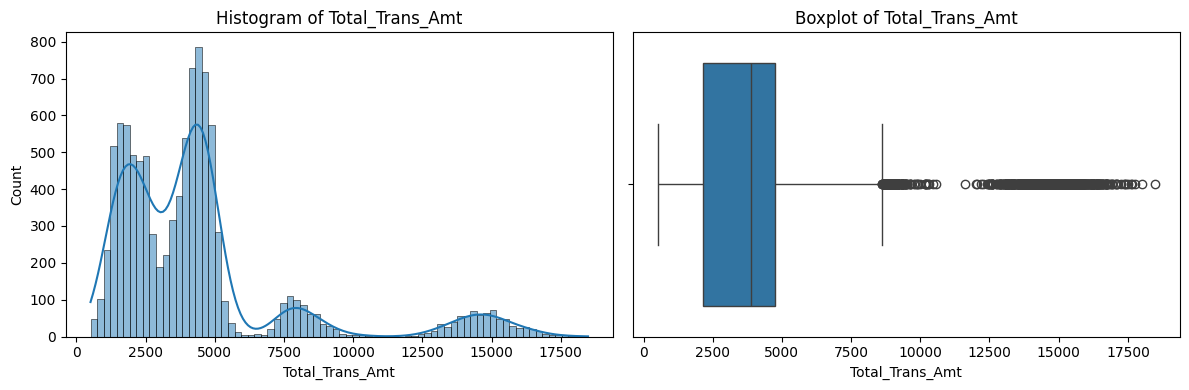

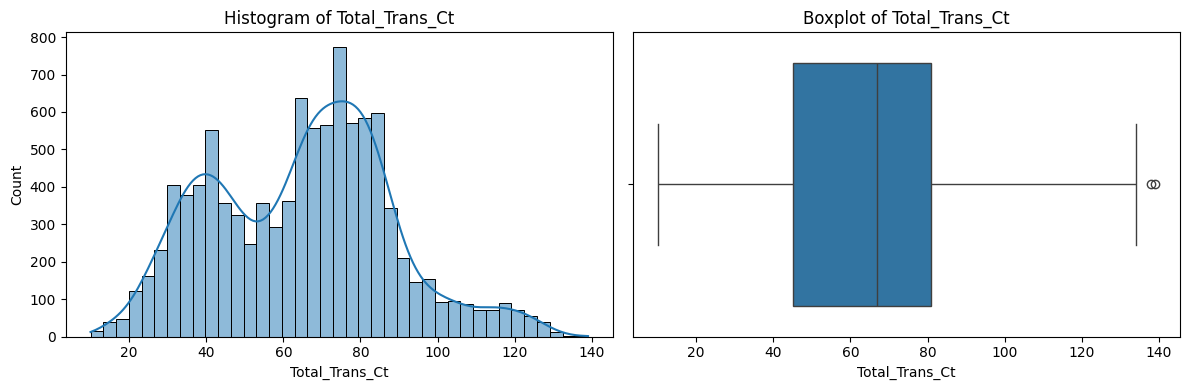

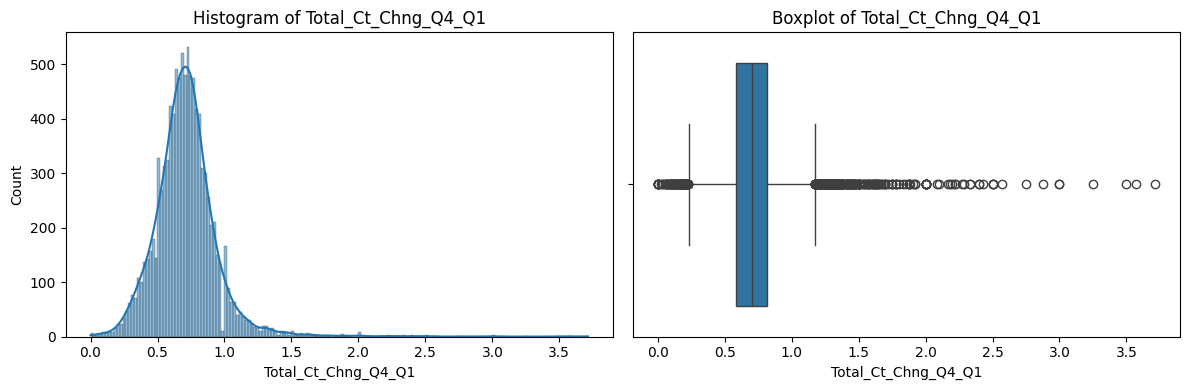

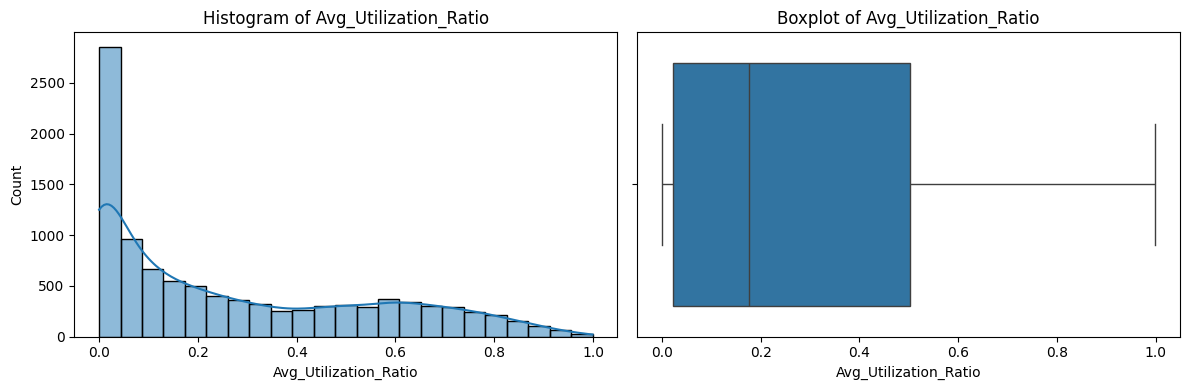

In [17]:
# 연속형 변수 확인
for col in continuous_cols:
    
    fig, axes = plt.subplots(1, 2, figsize=(12,4))
    
    # Histogram
    sns.histplot(df[col], kde=True, ax=axes[0])
    axes[0].set_title(f'Histogram of {col}')
    
    # Boxplot
    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f'Boxplot of {col}')
    
    plt.tight_layout()
    plt.show()

### 2. 데이터 전처리 / 피쳐 엔지니어링

> 데이터 전처리

In [18]:
# 분석에 필요없는 고객ID, Attrition_Flag와 정보가 중복되는 변수 삭제
df = df.drop(columns=['CLIENTNUM', 'Attrition_Flag', 'Avg_Open_To_Buy', 'Total_Ct_Chng_Q4_Q1'])

**Credit_Limit & Avg_Open_To_Buy**
* (Avg_Open_To_Buy = Credit_Limit - Total_Revolving_Bal)라는 계산으로 만들어지는 **파생 변수**이므로, 여기서 Avg_Open_To_Buy를 삭제 (관행에 따라)

**Total_Amt_Chng_Q4_Q1 & Total_Ct_Chng_Q4_Q1**
* 두 변수 모두 **최근 소비 변화**를 나타낸다. 보통 금액 변화가 이탈률 설명력이 큰 경우가 많다고 하여, Total_Ct_Chng_Q4_Q1를 삭제

In [19]:
# 변수명 수정
df = df.rename(columns={
    'Customer_Age':'age',
    'Gender':'gender',
    'Dependent_count':'family',
    'Education_Level':'education',
    'Marital_Status':'marriage',
    'Income_Category':'income',
    'Card_Category':'card_category',
    'Months_on_book':'hold_month',
    'Total_Relationship_Count':'product_count',
    'Months_Inactive_12_mon':'inactive_12m',
    'Contacts_Count_12_mon':'contacts_12m',
    'Credit_Limit':'credit_limit',
    'Total_Revolving_Bal':'revolving_balance',
    'Total_Amt_Chng_Q4_Q1':'amt_change_q4_q1',
    'Total_Trans_Amt':'total_trans_amt',
    'Total_Trans_Ct':'total_trans_cnt',
    'Avg_Utilization_Ratio':'utilization_ratio'})

df.head()

,age,gender,family,education,marriage,income,card_category,hold_month,product_count,inactive_12m,contacts_12m,credit_limit,revolving_balance,amt_change_q4_q1,total_trans_amt,total_trans_cnt,utilization_ratio,churn
0,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,1.335,1144,42,0.061,0
1,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,1.541,1291,33,0.105,0
2,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,2.594,1887,20,0.000,0
3,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,1.405,1171,20,0.760,0
4,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,2.175,816,28,0.000,0


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                10127 non-null  int64  
 1   gender             10127 non-null  object 
 2   family             10127 non-null  int64  
 3   education          10127 non-null  object 
 4   marriage           10127 non-null  object 
 5   income             10127 non-null  object 
 6   card_category      10127 non-null  object 
 7   hold_month         10127 non-null  int64  
 8   product_count      10127 non-null  int64  
 9   inactive_12m       10127 non-null  int64  
 10  contacts_12m       10127 non-null  int64  
 11  credit_limit       10127 non-null  float64
 12  revolving_balance  10127 non-null  int64  
 13  amt_change_q4_q1   10127 non-null  float64
 14  total_trans_amt    10127 non-null  int64  
 15  total_trans_cnt    10127 non-null  int64  
 16  utilization_ratio  101

결측치가 없는 것으로 보이지만, **education, marriage, income**에 **"unknown"** 칼럼을 발견했다.

In [47]:
# 3개 변수에서 unknown의 실제 표본 수 및 비율은 어떻게 되는가?
unknown_cols = ['education','marriage','income']

for col in unknown_cols:
    total_n = len(df)
    unknown_n = (df[col] == 'Unknown').sum()
    unknown_ratio = (df[col] == 'Unknown').mean() * 100
    
    print(f'[{col}]')
    print(f'전체 표본 수: {total_n}')
    print(f'Unknown 표본 수: {unknown_n}')
    print(f'Unknown 비율: {unknown_ratio:.2f}%')
    print('-' * 40)

[education]
전체 표본 수: 10127
Unknown 표본 수: 1519
Unknown 비율: 15.00%
----------------------------------------
[marriage]
전체 표본 수: 10127
Unknown 표본 수: 749
Unknown 비율: 7.40%
----------------------------------------
[income]
전체 표본 수: 10127
Unknown 표본 수: 1112
Unknown 비율: 10.98%
----------------------------------------


unknown 집단의 표본 수가 무시하기 어려운 수준이고, 다른 범주와 비교했을 때 단순한 결측이라고 보기 어렵다고 판단하여 삭제하지 않고 그대로 유지.

(보통 이탈률 분석에서 Unknown인 이유가 있다고 보고, 특정 고객군이라 생각하고 분석을 진행한다고 한다.)

이상치: EDA 탐색에서 boxplot으로 확인했을 때 이탈률 = 1인 특성이 있었다: **contacts_12m**

In [49]:
# contacts_12m 범주 데이터 확인
summary = df.groupby('contacts_12m')['churn'].agg(['count', 'mean'])
print(f'\n[{col}]')
print(summary)


[income]
              count      mean
contacts_12m                 
0               399  0.017544
1              1499  0.072048
2              3227  0.124884
3              3380  0.201479
4              1392  0.226293
5               176  0.335227
6                54  1.000000


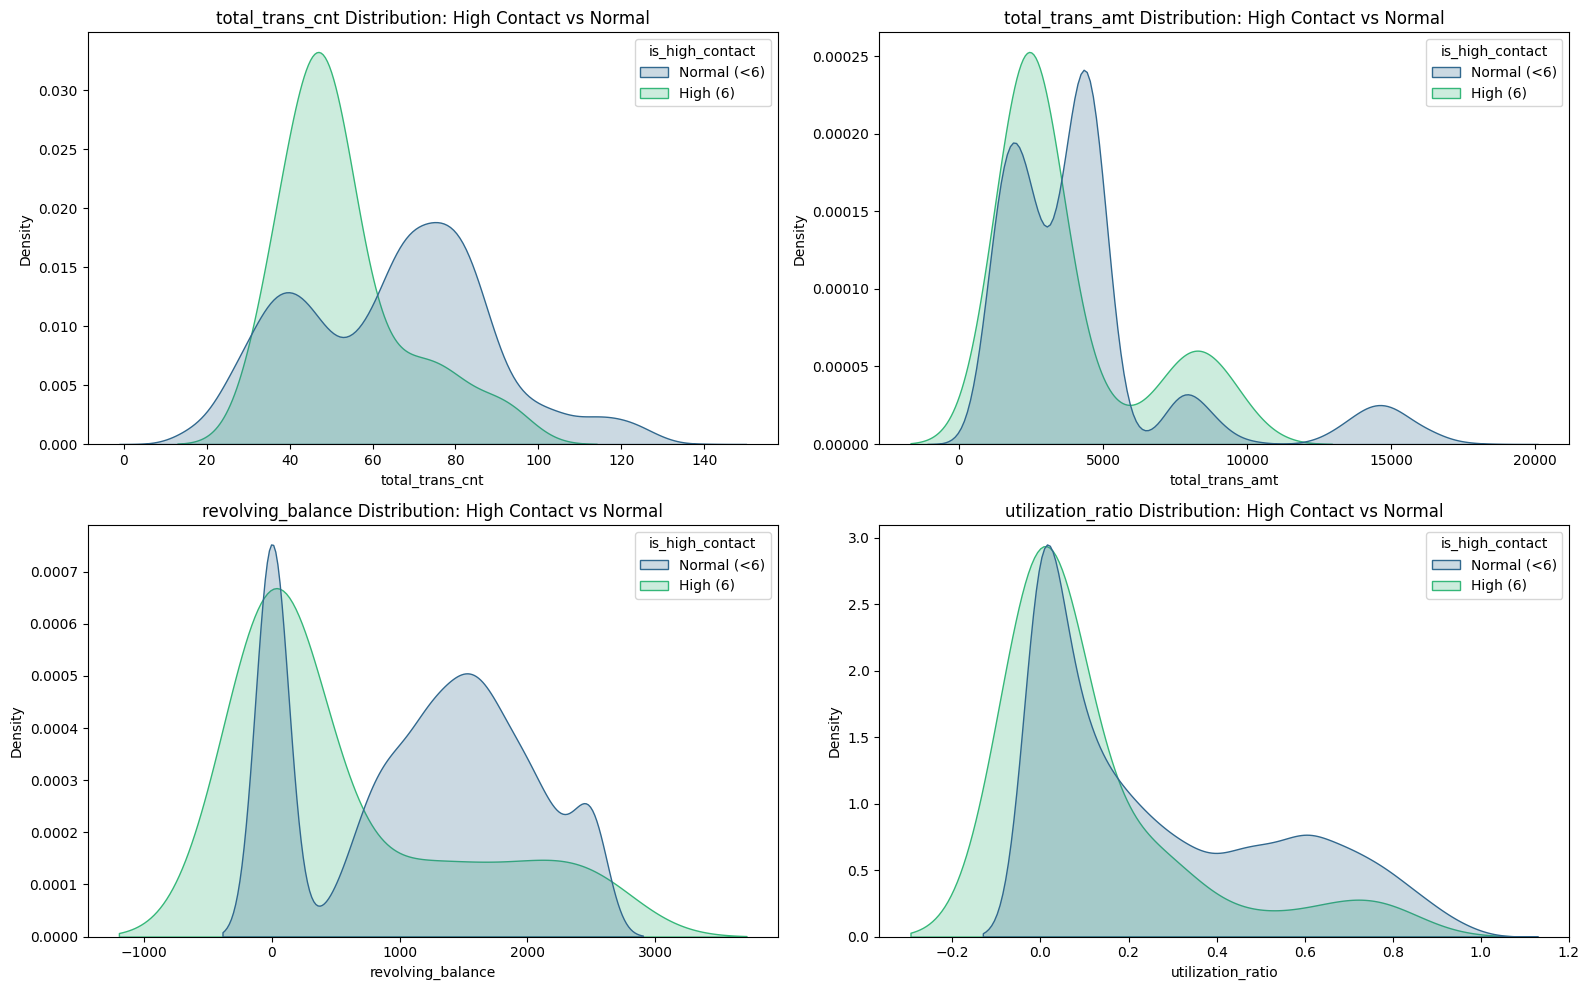

In [ ]:
# 그룹 분리 
high_contact_group = df[df['contacts_12m'] == 6]
normal_group = df[df['contacts_12m'] < 6]

# 비교를 위해 타겟 변수 추가
df['is_high_contact'] = df['contacts_12m'].apply(lambda x: 'High (6)' if x == 6 else 'Normal (<6)')

# 주요 수치형 변수 비교 시각화 (KDE Plot)
# 이탈과 밀접한 관련이 있는 변수들 위주로 선정
key_num_cols = ['total_trans_cnt', 'total_trans_amt', 'revolving_balance', 'utilization_ratio']

plt.figure(figsize=(16, 10))
for i, col in enumerate(key_num_cols):
    plt.subplot(2, 2, i+1)
    sns.kdeplot(data=df, x=col, hue='is_high_contact', common_norm=False, fill=True, palette='viridis')
    plt.title(f'{col} Distribution: High Contact vs Normal')

plt.tight_layout()
plt.show()

고객센터 접촉 횟수가 많은 집단에서 나타나는 특징이 보인다
: 최근 12개월 간 거래 횟수 감소, 리볼빙 잔액 감소

하지만 이상치로 판단하기는 어렵다. (표본수가 54개이기도 하고, 다른 변수들의 분포가 한쪽에 치우쳐있지도 않다.)

> 피쳐 엔지니어링

In [21]:
# 파생변수 생성
# 거래 1회 평균 금액
df['avg_trans_amt'] = df['total_trans_amt'] / df['total_trans_cnt']

# 월 평균 거래 횟수
df['monthly_trans'] = df['total_trans_cnt'] / df['hold_month']

# 카드 의존도
df['spending_ratio'] = df['total_trans_amt'] / df['credit_limit']

# 활동 점수
df['activity_score'] = df['total_trans_cnt'] * (1 - df['inactive_12m']/12)

In [24]:
# 파생변수의 분포 확인
add_features = ['avg_trans_amt', 'monthly_trans', 'spending_ratio', 'activity_score']

df[add_features].describe()

,avg_trans_amt,monthly_trans,spending_ratio,activity_score
count,10127.000000,10127.000000,10127.000000,10127.000000
mean,62.612717,1.923120,1.041935,52.289515
std,26.404198,0.911977,0.937981,20.058087
min,19.137931,0.188679,0.018105,7.500000
25%,47.514573,1.272727,0.303473,35.750000
50%,55.794872,1.857143,0.727143,53.250000
75%,65.476673,2.361111,1.553307,65.833333
max,190.193182,9.769231,5.080247,120.083333


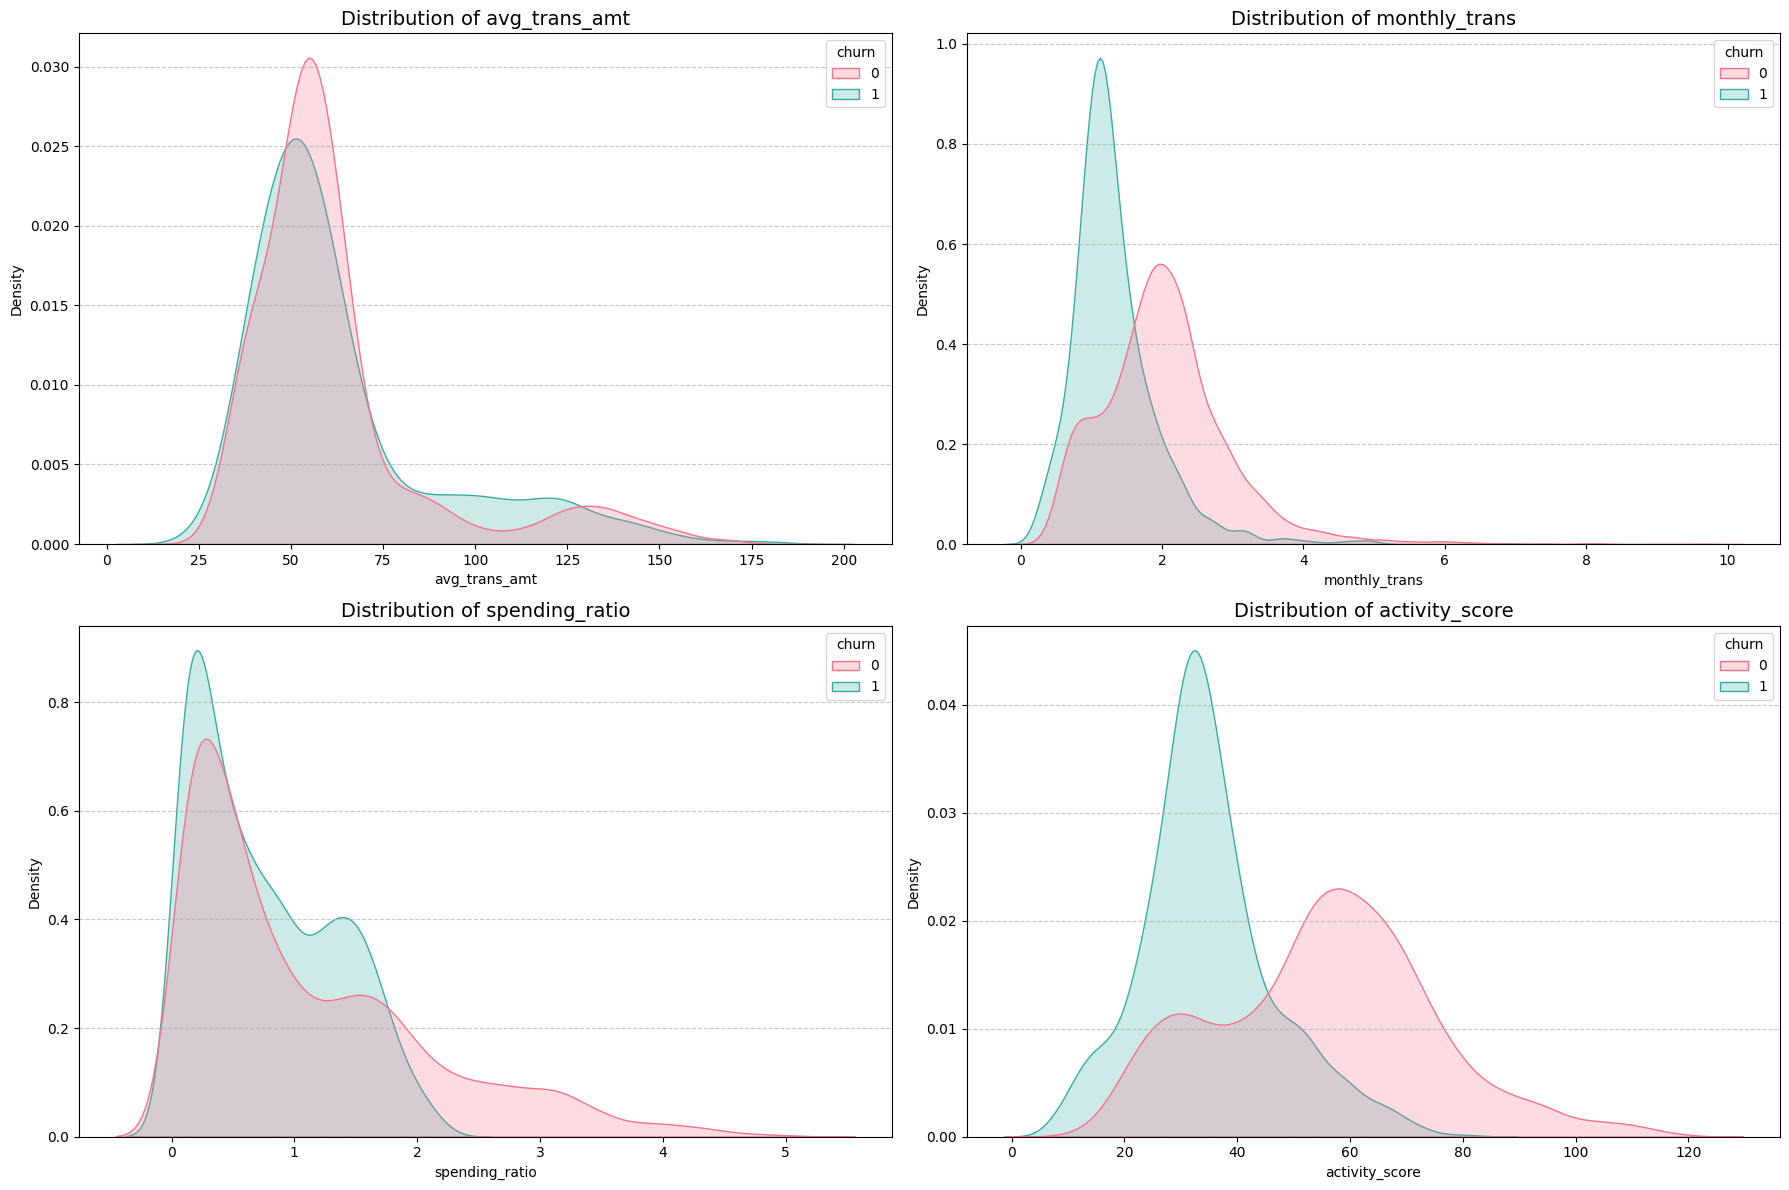

In [25]:
# 그래프로 확인
plt.figure(figsize=(18, 12))

for i, col in enumerate(add_features):
    plt.subplot(2, 2, i+1)
    # KDE Plot으로 밀도 분포 확인 (이탈 여부에 따라 색상 구분)
    sns.kdeplot(data=df, x=col, hue='churn', fill=True, common_norm=False, palette='husl')
    plt.title(f'Distribution of {col}', fontsize=14)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

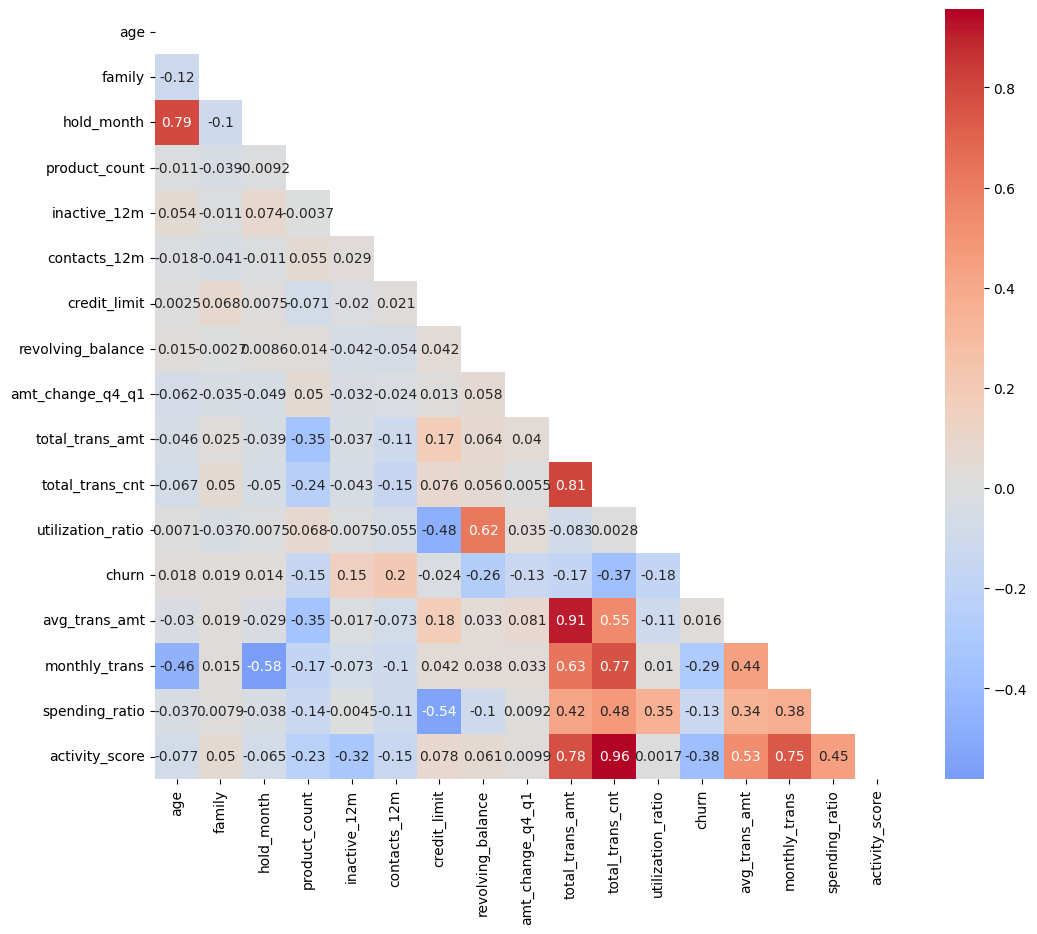

In [26]:
# 변수들 간 상관관계 확인
corr = df.corr(numeric_only=True)

mask = np.triu(np.ones_like(corr))

plt.figure(figsize=(12,10))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.show()

In [ ]:
# 다중공선성 의심, VIF 확인
# 수치형 변수만 추출 (VIF 계산용)
numeric_df = df.select_dtypes(include=[np.number]).dropna()

vif_data = pd.DataFrame()
vif_data["feature"] = numeric_df.columns
vif_data["VIF"] = [variance_inflation_factor(numeric_df.values, i) for i in range(len(numeric_df.columns))]

print(vif_data.sort_values(by="VIF", ascending=False))

              feature         VIF
10    total_trans_cnt  805.642809
16     activity_score  708.578838
2          hold_month  107.300539
0                 age   87.562205
13      avg_trans_amt   78.485595
9     total_trans_amt   59.580843
4        inactive_12m   49.536419
14      monthly_trans   38.103961
8    amt_change_q4_q1   13.265125
7   revolving_balance    8.428249
3       product_count    8.101105
11  utilization_ratio    6.945705
15     spending_ratio    6.851054
5        contacts_12m    6.159742
1              family    4.344399
6        credit_limit    4.240040
12              churn    1.877525


파생변수들이 VIF를 매우 높게 만들어버렸다..

추후 모델링 과정에서 다중공선성에 강한 모델 활용

### 3. 모델링 / 모델 평가

> 모델 선정

In [31]:
# 3분할로 데이터 쪼개기
X = df.drop('churn', axis=1)
y = df['churn']

# 먼저 Test를 떼어내기(20%)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 남은 80%를 Train(60%)과 Valid(20%)로 나누기
X_train, X_valid, y_train, y_valid = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

# 인코딩 동기화 (Train 기준으로 맞춤)
X_train_enc = pd.get_dummies(X_train, drop_first=True)
X_valid_enc = pd.get_dummies(X_valid, drop_first=True).reindex(columns=X_train_enc.columns, fill_value=0)
X_test_enc  = pd.get_dummies(X_test,  drop_first=True).reindex(columns=X_train_enc.columns, fill_value=0)

1) Random Forest

In [32]:
# 1. 탐색할 파라미터 범위 설정 (나사 조절 범위)
param_dist = {
    'n_estimators': [100, 200, 300, 500], # 나무 개수
    'max_depth': [None, 10, 20, 30],      # 나무 깊이
    'min_samples_split': [2, 5, 10],      # 가지를 치기 위한 최소 샘플 수
    'max_features': ['sqrt', 'log2']      # 각 나무가 사용할 변수 개수
}

# 2. 자동 튜닝 알고리즘 설정
# scoring='recall'로 설정하여 이탈자를 잘 잡는 최적의 조합을 찾습니다.
# cv=5로 Train 데이터 안에서만 5조각으로 쪼개서 튜닝한다
rf_random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=10, cv=5, scoring='recall', n_jobs=-1, random_state=42
)

# 3. 학습 진행
rf_random_search.fit(X_train_enc, y_train)

# 4. 최적의 모델과 결과 확인
best_rf = rf_random_search.best_estimator_
print(f"✅ [RandomForest] 최적 파라미터: {rf_random_search.best_params_}")

# 5. Valid 셋으로 '진짜 성능' 평가
y_val_pred = best_rf.predict(X_valid_enc)

print(f"\n📊 Validation 셋 Recall: {recall_score(y_valid, y_val_pred):.4f}")
print("\n[Validation 셋 Classification Report]")
print(classification_report(y_valid, y_val_pred))

✅ [RandomForest] 최적 파라미터: {'n_estimators': 500, 'min_samples_split': 5, 'max_features': 'sqrt', 'max_depth': 30}

📊 Validation 셋 Recall: 0.7883

[Validation 셋 Classification Report]
              precision    recall  f1-score   support

           0       0.96      0.99      0.97      1700
           1       0.91      0.79      0.85       326

    accuracy                           0.95      2026
   macro avg       0.94      0.89      0.91      2026
weighted avg       0.95      0.95      0.95      2026



2) XGBoost

In [33]:
# 1. 탐색할 파라미터 범위 설정 
xgb_param_dist = {
    'n_estimators': [100, 200, 300, 500],    # 나무 개수
    'max_depth': [3, 5, 7, 10],              # 나무 깊이 (RF보다 보통 얕게 설정)
    'learning_rate': [0.01, 0.05, 0.1, 0.2], # 학습률 (보폭)
    'subsample': [0.6, 0.8, 1.0],            # 데이터 샘플링 비율 (과적합 방지)
    'colsample_bytree': [0.6, 0.8, 1.0]      # 사용할 변수 비율 (과적합 방지)
}

# 2. 자동 튜닝 알고리즘 설정
xgb_random_search = RandomizedSearchCV(
    # eval_metric='logloss'는 최신 버전의 불필요한 경고 메시지를 방지합니다.
    XGBClassifier(random_state=42, eval_metric='logloss'),
    param_distributions=xgb_param_dist,
    n_iter=10, cv=5, scoring='recall', n_jobs=-1, random_state=42
)

# 3. 학습 진행
xgb_random_search.fit(X_train_enc, y_train)

# 4. 최적의 모델과 결과 확인
best_xgb = xgb_random_search.best_estimator_
print(f"✅ [XGBoost] 최적 파라미터: {xgb_random_search.best_params_}")

# 5. Valid 셋으로 '진짜 성능' 평가
y_val_pred_xgb = best_xgb.predict(X_valid_enc)

print(f"\n📊 [XGBoost] Validation 셋 Recall: {recall_score(y_valid, y_val_pred_xgb):.4f}")
print("\n[Validation 셋 Classification Report]")
print(classification_report(y_valid, y_val_pred_xgb))

✅ [XGBoost] 최적 파라미터: {'subsample': 1.0, 'n_estimators': 300, 'max_depth': 10, 'learning_rate': 0.2, 'colsample_bytree': 0.8}

📊 [XGBoost] Validation 셋 Recall: 0.8620

[Validation 셋 Classification Report]
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1700
           1       0.92      0.86      0.89       326

    accuracy                           0.97      2026
   macro avg       0.95      0.92      0.94      2026
weighted avg       0.97      0.97      0.97      2026



3) LightGBM

In [34]:
# 1. 탐색할 파라미터 범위 설정 (LightGBM 맞춤형)
lgbm_param_dist = {
    'n_estimators': [100, 200, 300, 500],    # 나무 개수
    'max_depth': [-1, 5, 10, 20],            # 나무 깊이 (-1은 제한 없음을 의미)
    'learning_rate': [0.01, 0.05, 0.1, 0.2], # 학습률
    'num_leaves': [31, 63, 127],             # 하나의 트리가 가질 수 있는 최대 잎의 수 (LGBM 핵심)
    'subsample': [0.6, 0.8, 1.0],            # 데이터 샘플링 비율
    'colsample_bytree': [0.6, 0.8, 1.0]      # 사용할 변수 비율
}

# 2. 자동 튜닝 알고리즘 설정
lgbm_random_search = RandomizedSearchCV(
    # verbose=-1 은 LightGBM 특유의 길고 복잡한 학습 로그(경고창)를 숨겨줍니다.
    LGBMClassifier(random_state=42, verbose=-1),
    param_distributions=lgbm_param_dist,
    n_iter=10, cv=5, scoring='recall', n_jobs=-1, random_state=42
)

# 3. 학습 진행
lgbm_random_search.fit(X_train_enc, y_train)

# 4. 최적의 모델과 결과 확인
best_lgbm = lgbm_random_search.best_estimator_
print(f"✅ [LightGBM] 최적 파라미터: {lgbm_random_search.best_params_}")

# 5. Valid 셋으로 '진짜 성능' 평가
y_val_pred_lgbm = best_lgbm.predict(X_valid_enc)

print(f"\n📊 [LightGBM] Validation 셋 Recall: {recall_score(y_valid, y_val_pred_lgbm):.4f}")
print("\n[Validation 셋 Classification Report]")
print(classification_report(y_valid, y_val_pred_lgbm))

✅ [LightGBM] 최적 파라미터: {'subsample': 1.0, 'num_leaves': 63, 'n_estimators': 500, 'max_depth': 20, 'learning_rate': 0.05, 'colsample_bytree': 0.8}

📊 [LightGBM] Validation 셋 Recall: 0.8804

[Validation 셋 Classification Report]
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1700
           1       0.91      0.88      0.90       326

    accuracy                           0.97      2026
   macro avg       0.94      0.93      0.94      2026
weighted avg       0.97      0.97      0.97      2026



precision, recall, f1-score 모두 가장 높게 나타난 LightGBM으로 결정.

추가로, 3개 모델 모두 거래 관련 변수를 가장 중요하게 판단했고, 카드 등급의 중요도가 가장 낮게 나타났다. 

> 모델링

/tmp/ipykernel_58906/932747060.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=lgbm_importances.head(20).values, y=lgbm_importances.head(20).index, palette='viridis')


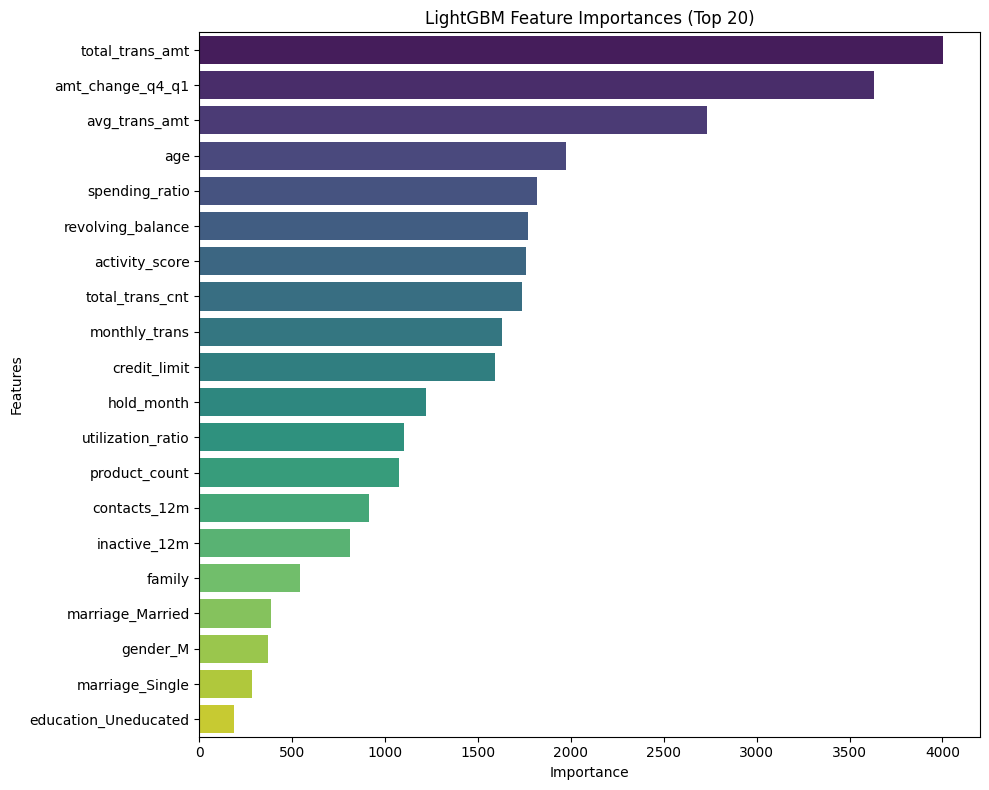


--- [LightGBM] 중요도 0 인 변수들 (1개) ---
['card_category_Platinum']

--- [LightGBM] 중요도 하위 15개 변수 ---
education_Uneducated       184
education_Graduate         143
income_$80K - $120K        135
income_$60K - $80K         116
income_Less than $40K      114
education_Unknown           94
income_$40K - $60K          93
education_High School       71
education_Doctorate         68
marriage_Unknown            66
income_Unknown              58
education_Post-Graduate     32
card_category_Silver        27
card_category_Gold           2
card_category_Platinum       0
dtype: int32


In [35]:
# 변수 중요도 확인
# 1. LightGBM 변수 중요도 추출 및 정렬
lgbm_importances = pd.Series(best_lgbm.feature_importances_, index=X_train_enc.columns).sort_values(ascending=False)

# 2. 상위 20개 중요 변수 시각화
plt.figure(figsize=(10, 8))
sns.barplot(x=lgbm_importances.head(20).values, y=lgbm_importances.head(20).index, palette='viridis')
plt.title('LightGBM Feature Importances (Top 20)')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# 3. 중요도가 0인 변수들 확인
zero_importance_cols = lgbm_importances[lgbm_importances == 0].index.tolist()
print(f"\n--- [LightGBM] 중요도 0 인 변수들 ({len(zero_importance_cols)}개) ---")
print(zero_importance_cols)

# 4. 중요도 하위 15개 변수 확인
print("\n--- [LightGBM] 중요도 하위 15개 변수 ---")
print(lgbm_importances.tail(15))

In [36]:
# 중요도 낮은 변수 삭제 후 다시 모델링
# 1. 삭제할 변수 리스트
drop_cols = [
    'card_category_Silver', 'card_category_Gold', 'card_category_Platinum',
    'education_High School', 'income_$40K - $60K', 'education_unknown', 'income_unnknown',
    'marriage_unknown', 'education_Doctorate', 'education_Post-Graduate'
]

# 2. Train, Valid, Test 모두에서 동일하게 날리기
X_train_slim = X_train_enc.drop(columns=drop_cols, errors='ignore')
X_valid_slim = X_valid_enc.drop(columns=drop_cols, errors='ignore')
X_test_slim  = X_test_enc.drop(columns=drop_cols, errors='ignore')

print(f"🔥 피처 다이어트 완료!")
print(f"기존 컬럼 수: {X_train_enc.shape[1]}개 -> Slim 컬럼 수: {X_train_slim.shape[1]}개")
print(f"총 {X_train_enc.shape[1] - X_train_slim.shape[1]}개의 불필요한 노이즈가 제거되었습니다.")

🔥 피처 다이어트 완료!
기존 컬럼 수: 34개 -> Slim 컬럼 수: 27개
총 7개의 불필요한 노이즈가 제거되었습니다.


In [37]:
# 1. 1단계에서 사용했던 파라미터 탐색 범위 그대로 가져오기
lgbm_param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [-1, 5, 10, 20],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'num_leaves': [31, 63, 127],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

# 2. 자동 튜닝 알고리즘 설정 (Slim 데이터 기준)
lgbm_slim_search = RandomizedSearchCV(
    LGBMClassifier(random_state=42, verbose=-1),
    param_distributions=lgbm_param_dist,
    n_iter=10, cv=5, scoring='recall', n_jobs=-1, random_state=42
)

# 3. Slim Train 데이터로 학습 진행
print("🚀 Slim 데이터로 LightGBM 하이퍼파라미터 튜닝을 시작합니다...")
lgbm_slim_search.fit(X_train_slim, y_train)

# 4. 최적의 Slim 모델 추출
best_lgbm_slim = lgbm_slim_search.best_estimator_
print(f"\n✅ [Slim 모델] 최적 파라미터: {lgbm_slim_search.best_params_}")

# 5. Valid 셋으로 '진짜 성능' 평가
y_val_pred_slim = best_lgbm_slim.predict(X_valid_slim)

print(f"\n📊 [Slim 모델] Validation 셋 Recall: {recall_score(y_valid, y_val_pred_slim):.4f}")
print("\n[Slim 모델 Validation 셋 Classification Report]")
print(classification_report(y_valid, y_val_pred_slim))

🚀 Slim 데이터로 LightGBM 하이퍼파라미터 튜닝을 시작합니다...

✅ [Slim 모델] 최적 파라미터: {'subsample': 0.8, 'num_leaves': 31, 'n_estimators': 200, 'max_depth': 20, 'learning_rate': 0.2, 'colsample_bytree': 0.8}

📊 [Slim 모델] Validation 셋 Recall: 0.8865

[Slim 모델 Validation 셋 Classification Report]
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1700
           1       0.93      0.89      0.91       326

    accuracy                           0.97      2026
   macro avg       0.96      0.94      0.95      2026
weighted avg       0.97      0.97      0.97      2026



In [38]:
# 불균형 데이터 가중치 조절
# 1. 훈련 데이터의 불균형 비율(가중치) 계산
# 가중치 = (정상 고객 수) / (이탈 고객 수)
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
optimal_weight = neg_count / pos_count

print(f"⚖️ 정상 고객 수: {neg_count}명, 이탈 고객 수: {pos_count}명")
print(f"⚖️ 권장되는 scale_pos_weight: {optimal_weight:.2f}")

# 2. 3단계에서 찾은 최적의 파라미터 가져오기
best_params = best_lgbm_slim.get_params()

# 3. 모델에 가중치 덮어씌우기
best_params['scale_pos_weight'] = optimal_weight

# 4. 가중치가 적용된 새로운 모델 생성 및 학습
lgbm_weighted = LGBMClassifier(**best_params)
lgbm_weighted.fit(X_train_slim, y_train)

# 5. Valid 셋으로 성능 평가
y_val_pred_weighted = lgbm_weighted.predict(X_valid_slim)

print(f"\n📊 [가중치 적용 모델] Validation 셋 Recall: {recall_score(y_valid, y_val_pred_weighted):.4f}")
print(f"📊 [가중치 적용 모델] Validation 셋 Precision: {precision_score(y_valid, y_val_pred_weighted):.4f}")
print("\n[가중치 적용 모델 Validation 셋 Classification Report]")
print(classification_report(y_valid, y_val_pred_weighted))

⚖️ 정상 고객 수: 5099명, 이탈 고객 수: 976명
⚖️ 권장되는 scale_pos_weight: 5.22

📊 [가중치 적용 모델] Validation 셋 Recall: 0.8957
📊 [가중치 적용 모델] Validation 셋 Precision: 0.9241

[가중치 적용 모델 Validation 셋 Classification Report]
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1700
           1       0.92      0.90      0.91       326

    accuracy                           0.97      2026
   macro avg       0.95      0.94      0.95      2026
weighted avg       0.97      0.97      0.97      2026



> 모델 평가

In [ ]:
# 성능 지표 확인하기
# 1. Test set으로 예측
final_model = lgbm_weighted 

y_test_pred = final_model.predict(X_test_slim)
y_test_proba = final_model.predict_proba(X_test_slim)[:, 1]

# 2. 핵심 성능 지표 출력
# ROC-AUC Score
print("🚀 [최종 Test Set 성능 평가 보고서] 🚀")
print("-" * 50)
print(f"✅ ROC-AUC Score : {roc_auc_score(y_test, y_test_proba):.4f}")

# 불균형 데이터의 핵심 지표(PR-AUC Score)
print(f"✅ PR-AUC Score  : {average_precision_score(y_test, y_test_proba):.4f}")
print("-" * 50)

print("\n[Classification Report]")
print(classification_report(y_test, y_test_pred))

🚀 [최종 Test Set 성능 평가 보고서] 🚀
--------------------------------------------------
✅ ROC-AUC Score : 0.9898
✅ PR-AUC Score  : 0.9575
--------------------------------------------------

[Classification Report]
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1701
           1       0.90      0.88      0.89       325

    accuracy                           0.97      2026
   macro avg       0.94      0.93      0.94      2026
weighted avg       0.97      0.97      0.97      2026



ROC-AUC Score : 0.9898 
* 임의의 이탈자와 정상 고객을 비교했을 때, 모델이 이탈 고객을 더 높은 위험도로 판단할 확률이 약 99%로 매우 높은 구분 능력을 보인다.

PR-AUC Score  : 0.9575 
* 일탈 고객 탐지에서 Precision과 Recall 간 균형이 우수하다. 높은 Recall을 유지하면서도, 불필요한 오탐지를 효과적으로 억제한다.

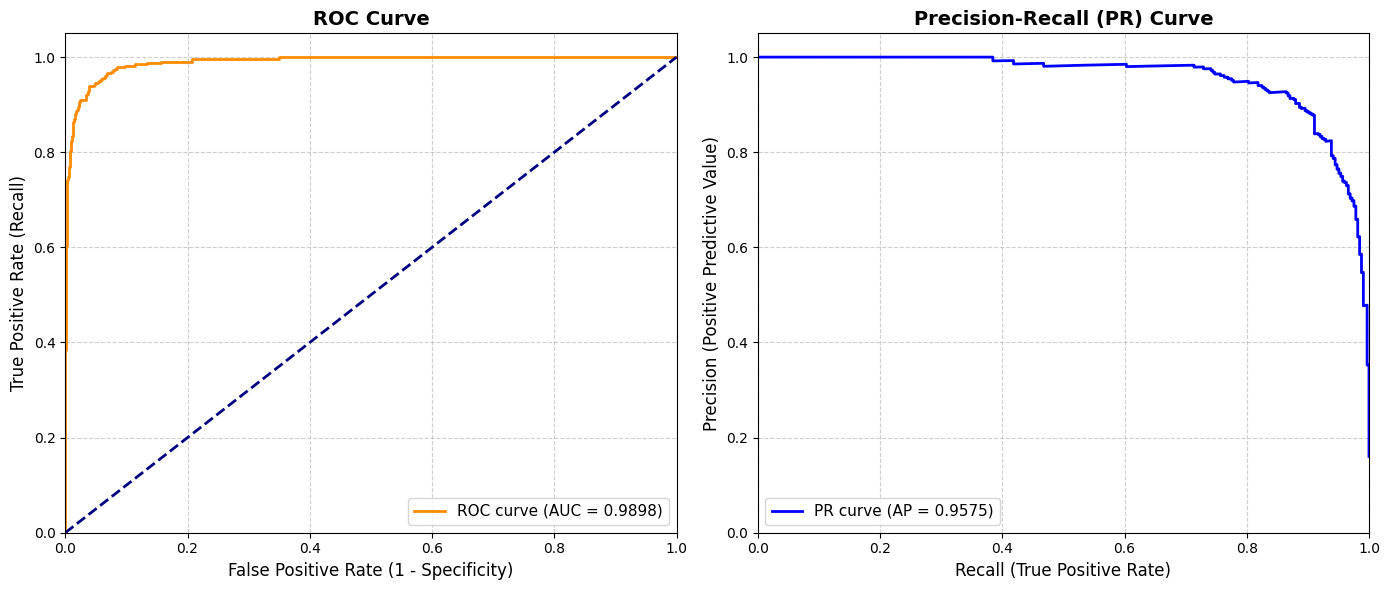

In [40]:
# Curve로 확인하기
# 1. 평가 지표 계산
# ROC Curve 데이터
fpr, tpr, roc_thresholds = roc_curve(y_test, y_test_proba)
roc_auc = auc(fpr, tpr)

# PR Curve 데이터
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_test_proba)
pr_auc = average_precision_score(y_test, y_test_proba)

# 2. 1행 2열 Subplot 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC Curve
axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
axes[0].set_ylabel('True Positive Rate (Recall)', fontsize=12)
axes[0].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[0].legend(loc="lower right", fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.6)

# PR Curve
axes[1].plot(recall, precision, color='blue', lw=2, label=f'PR curve (AP = {pr_auc:.4f})')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Recall (True Positive Rate)', fontsize=12)
axes[1].set_ylabel('Precision (Positive Predictive Value)', fontsize=12)
axes[1].set_title('Precision-Recall (PR) Curve', fontsize=14, fontweight='bold')
axes[1].legend(loc="lower left", fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.6)

# 레이아웃 겹침 방지 및 출력
plt.tight_layout()
plt.show()

* ROC-Curve: 선이 좌측 상단에 달라붙어 있다. 이탈 고객에게 더 높은 위험 점수를 부여할 확률이 약 99%이다. (변별력)

* PR-Curve: 가로축이 0.8~0.9(이탈자 80~90% 검출)에 도달할 때까지 세로축(정밀도)이 1.0 부근을 유지하고 있다.(정교함)

이탈 고객을 90% 가까이 탐지하면서, 정상 고객을 이탈 고객으로 잘못 탐지하는 것을 효과적으로 억제하고 있다.

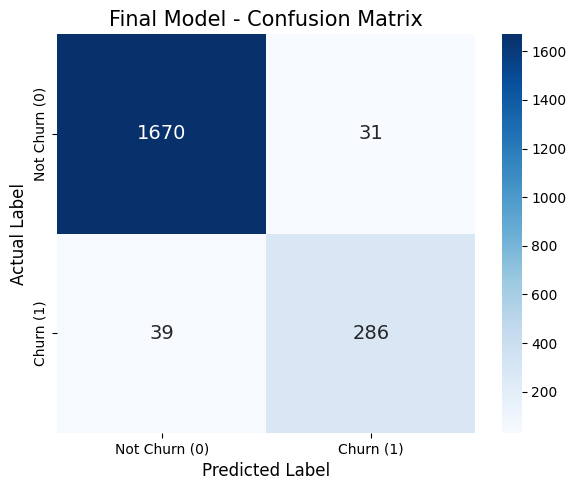

In [41]:
# 혼동 행렬(Confusion Matrix) 확인
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Churn (0)', 'Churn (1)'], 
            yticklabels=['Not Churn (0)', 'Churn (1)'],
            annot_kws={"size": 14})
plt.title('Final Model - Confusion Matrix', fontsize=15)
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

True Positive(TP), 우측 하단: 286명
* 실제로 카드를 해지하려던 고객 중 286명을 정확히 찾아냈다.
* 이탈자 총 325명 중 88%를 잡아냈다.

True Negative(TN), 좌측 상단: 1,670명
* 정상 고객 1,670명을 정확하게 안 떠날 사람으로 분류했다.

False Positive(FP), 우측 상단: 31명
* 실제로는 떠나지 않을 고객인데, 모델이 이탈할 것이라고 오해한 케이스
* 전체 정상 고객(1,701명) 중 단 1.8%(31명)에게만 오탐지가 일어났다. 

False Negative(FN), 좌측 하단: 39명
* 모델이 정상 고객이라고 판단했는데, 카드를 해지한 고객들

### 4. 모델 디벨롭 / 인사이트

> 모델 디벨롭

In [44]:
# 임계값 시뮬레이션으로 정밀도와 재현율 균형 확인하기
# 1. 모델의 예측 확률값 가져오기 (클래스 1일 확률)
y_val_probs = lgbm_weighted.predict_proba(X_valid_slim)[:, 1]

# 2. 임계값 후보군 설정 (0.05부터 0.95까지)
thresholds = np.arange(0.05, 1.0, 0.05)
results = []

for thres in thresholds:
    # 임계값 적용
    y_pred_temp = (y_val_probs >= thres).astype(int)
    
    # 지표 계산
    prec = precision_score(y_valid, y_pred_temp)
    rec = recall_score(y_valid, y_pred_temp)
    f1 = f1_score(y_valid, y_pred_temp)
    
    results.append({'Threshold': thres, 'Precision': prec, 'Recall': rec, 'F1-Score': f1})

# 3. 결과 테이블 출력
df_results = pd.DataFrame(results)
print(df_results.sort_values(by='F1-Score', ascending=False)) # F1-Score 기준 내림차순

    Threshold  Precision    Recall  F1-Score
3        0.20   0.906061  0.917178  0.911585
11       0.60   0.926984  0.895706  0.911076
4        0.25   0.911043  0.911043  0.911043
10       0.55   0.924051  0.895706  0.909657
9        0.50   0.924051  0.895706  0.909657
2        0.15   0.893491  0.926380  0.909639
7        0.40   0.913313  0.904908  0.909091
6        0.35   0.913313  0.904908  0.909091
8        0.45   0.921136  0.895706  0.908243
1        0.10   0.879310  0.938650  0.908012
5        0.30   0.910494  0.904908  0.907692
12       0.65   0.929260  0.886503  0.907378
13       0.70   0.928571  0.877301  0.902208
16       0.85   0.940000  0.865031  0.900958
0        0.05   0.855956  0.947853  0.899563
14       0.75   0.928105  0.871166  0.898734
15       0.80   0.933775  0.865031  0.898089
17       0.90   0.955017  0.846626  0.897561
18       0.95   0.964664  0.837423  0.896552


- 특별한 비즈니스 제약이 없다면 0.20을 사용하는 것이 모델의 통계적 성능을 가장 잘 뽑아내는 선택

- (이탈 방지 비용) < (고객 한 명을 잃는 손실)이라면, 임계값을 0.05까지 낮추는 공격적인 전략이 유효

- 마케팅 예산이 매우 한정되어 있다면 임계값을 0.95까지 높이는 것이 좋다

어떤 임계값을 설정할지는 비즈니스 상황에 따라 다르다!

--- [최종 결과] 임계값 0.2 적용 시 ---
Final Test ROC-AUC: 0.9898

[Classification Report]
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1701
           1       0.88      0.90      0.89       325

    accuracy                           0.97      2026
   macro avg       0.93      0.94      0.94      2026
weighted avg       0.97      0.97      0.97      2026



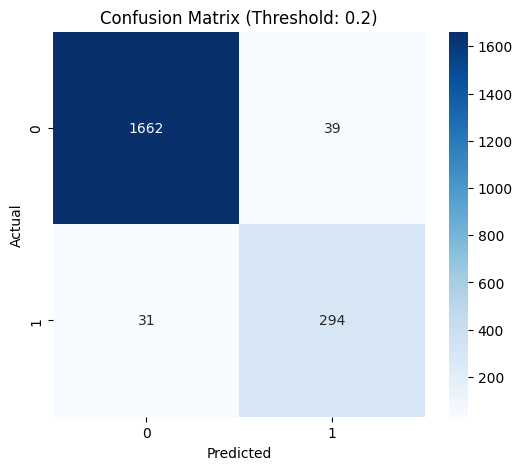

In [45]:
# 임계값 0.2로 결정하고 최종 모델 성능 확인
# 1. 테스트 데이터에 대해 이탈 확률(Probability) 예측
y_test_probs = lgbm_weighted.predict_proba(X_test_slim)[:, 1]

# 2. 최적 임계값 0.2 적용
custom_threshold = 0.2
y_test_pred_final = (y_test_probs >= custom_threshold).astype(int)

# 3. 최종 성능 지표 출력
print(f"--- [최종 결과] 임계값 {custom_threshold} 적용 시 ---")
print(f"Final Test ROC-AUC: {roc_auc_score(y_test, y_test_probs):.4f}")
print("\n[Classification Report]")
print(classification_report(y_test, y_test_pred_final))

# 4. 혼동 행렬(Confusion Matrix) 시각화
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_test_pred_final), annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix (Threshold: {custom_threshold})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

이전 모델과 비교
* f1-score는 동일, precision 0.2 감소하고 recall 0.2 증가했다.
* 정상 고객 8명 덜 정확하게 분류했으나, 이탈 고객 8명을 더 잡아냈다.

카드 이탈 방지가 중요하므로 위의 모델을 최종 모델로 선정!

> 인사이트

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


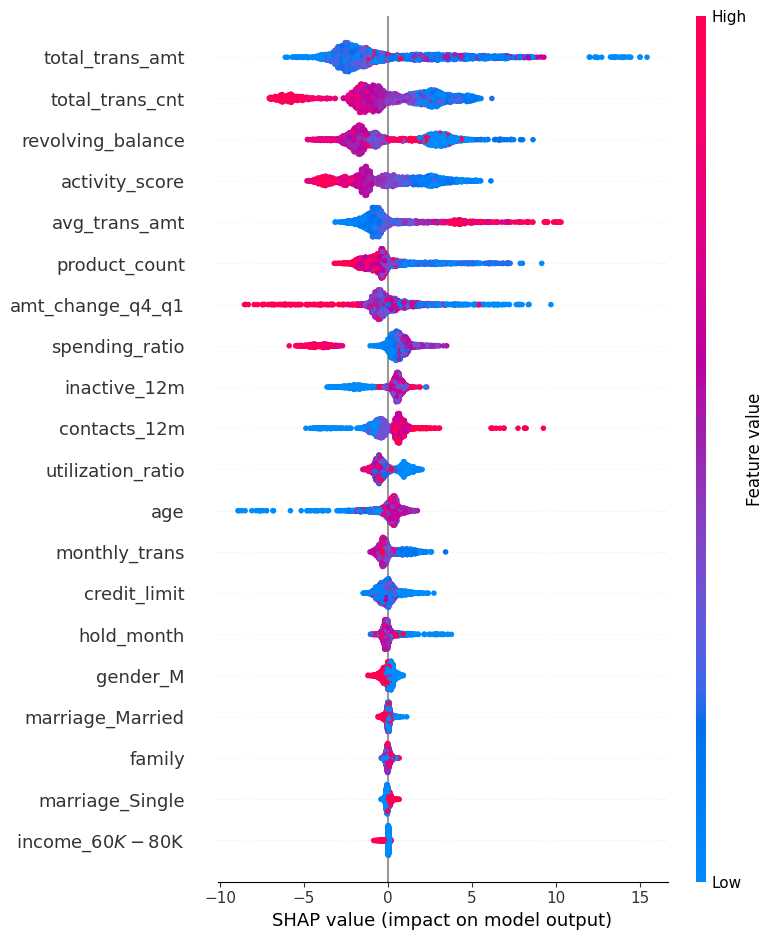

In [46]:
import shap

# 1. Explainer 및 shap_values 계산
explainer = shap.TreeExplainer(lgbm_weighted)
shap_values = explainer.shap_values(X_test_slim)

shap_to_plot = shap_values

# 3. Summary Plot 출력
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_to_plot, X_test_slim)

해석
* total_trans_amt(총 거래 금액)

거래 금액이 낮을수록(파란색) 이탈 확률을 높이는 경향이 있다.

* total_trans_cnt(총 거래 횟수)

거래 횟수가 많을수록(빨간색) 이탈 확률이 낮다.

* revolving_balance(리볼빙 잔액)

리볼빙 잔액이 높을수록 이탈 확률이 낮다.

* activity_score(활동지수)

활동성이 높을 수록 이탈 확률이 낮다.

* avg_trans_amt(평균 거래 금액)

평균 거래 금액이 높을수록 이탈 확률 높다. (+소액으로 자주 쓰는 고객이 더 유지?) 

* product_count(상품 가입 개수)

상품 많이 보유하고 있을 수록 이탈 확률이 낮다.

* amt_change_q4_q1

최근 소비가 감소한 것은 강력한 이탈 신호가 된다.

* contacts_12m(12개월간 고객센터 접촉 횟수)

고객의 문의가 많을수록 이탈 확률이 높아진다.

* inactive_12m(비활성 기간)

비활성 기간이 길 수록 이탈 확률 높아진다.

* 인구통계학적 변수들(age, gender, marriage, income)은 중요도가 대부분 낮게 나타난다. 

***

#### 📍 요약 및 시사점

✅ **활동성 지표가 핵심** 

total_trans_cnt, total_trans_amt, activity_score 같은 활동 관련 변수들이 최상단에 위치한다. 고객이 얼마나 자주, 많이 서비스를 이용하는지가 예측의 가장 중요한 척도가 된다.

❗️ 부정적 신호 (High Risk 고객 특징)
- 거래 횟수 ↓ (total_trans_cnt ↓)
- 거래 금액 ↓ (total_trans_amt ↓)
- 최근 소비 감소 (amt_change_q4_q1 ↓)
- 고객센터 접촉 ↑ (contacts_12m ↑)
- 비활성 기간 ↑ (inactive_12m ↑)

즉, “사용이 줄고 + 문제 접촉이 증가하는 고객” = 거의 이탈 직전


✅ **평균 거래금액의 해석**

avg_trans_amt가 높을수록 오히려 이탈 방향으로 작용했다.

“큰 금액을 가끔 쓰는 고객”보다 “작게라도 자주 쓰는 고객”이 더 안정적!

✅ **인구통계학적 변수의 낮은 영향력**  

차트 하단에 위치한 gender, marriage, income 등은 모델의 최종 판단에 미치는 영향이 상대적으로 매우 적다. 즉, "누구인가"보다 **"어떻게 행동하는가"**가 예측에 훨씬 중요하다.

> 결론: 카드 이탈은 고객 특성이 아닌 '사용 감소 패턴 + 불만'에서 발생한다

갑자기 떠나는 것이 아니라, 사용 감소 > 비활성화 > 불만 신호 증가라는 패턴을 통해 사전에 식별 가능하다!

***

#### ⊕ 향후 개선 방향
##### **1️⃣ 시간 흐름을 반영한 분석**

amt_change_q4_q1(전분기 대비 금액 변화) 변수(추세 관련)가 상위 중요도를 보였다.

-> 단순히 현재 상태가 아닌 변화의 방향성을 파악할 수 있는 파생 변수(예: 최근 기간 대비 거래금액/거래횟수 변화율)를 활용해본다던가, 시계열 특징을 추출한다면? 


##### **2️⃣ 모델 성능 개선**

Random Forest, XGBoost, LightGBM 3개 모델의 장점을 결합하는 **앙상블 기법(예: Stacking)**을 적용할 경우 추가적인 성능 향상을 기대할 수 있을 것.


##### **3️⃣ 세그먼트 기반 분석**

실제 데이터에서도 education, marriage, 부양 가족 수(family) 등 인구통계학적 변수에 따라 이탈률의 차이가 존재하는 것으로 확인되었다.

-> 인구통계학적 변수 기반으로 고객을 세분화해서 각 세그먼트별로 별도의 분석 또는 모델링을 수행한다면?